In [35]:
import pandas as pd # pyright: ignore[reportMissingModuleSource]
import matplotlib.pyplot as plt # pyright: ignore[reportMissingModuleSource]
import numpy as np # pyright: ignore[reportMissingModuleSource]


In [44]:
def convert_col_slf_to_lf(list_of_strings: [str]) -> [[float]]:
    """
    Function CONVERTS input

    FROM
      a column consisting of Strings of lists of floats
    TO
      a column consisting of lists of floats.
    """
    processed_list = []
    for row in list_of_strings:
        strip_paren = row[1:-1]
        row_split = strip_paren.split(",")
        processed_row = [float(val) for val in row_split]
        processed_list.append(processed_row)
    return processed_list

In [45]:
df = pd.read_csv('data.csv')
df.head()

,RAM Utilization,Largest Free Block (lfb),SWAP Space (RAM handling),CPU Utilization by core,RAM Bus Utilization (EMC),GPU Utilization,Temp POM,Temp CPU,Temp thermal,Temp AO
0,28.809284,441.0,0.0,"[12.0, 15.0, 10.0, 22.0]",0.0,0.0,41.0,41.0,41.5,43.0
1,28.809284,441.0,0.0,"[10.0, 11.0, 14.0, 18.0]",0.0,0.0,41.0,41.0,41.5,43.0
2,28.884965,441.0,0.0,"[45.0, 42.0, 50.0, 48.0]",10.0,0.0,43.5,43.5,44.0,44.5
3,29.011100,439.0,0.0,"[98.0, 95.0, 99.0, 96.0]",22.0,0.0,46.0,46.0,46.5,45.0
4,29.011100,439.0,0.0,"[99.0, 99.0, 98.0, 99.0]",24.0,0.0,48.5,48.5,49.0,46.5


In [70]:
num_rows = len(df) + 1
time_s = np.arange(5, num_rows*5, step=5)

ram_util = df['RAM Utilization']

num_cores = 4
core_util_unprocd = df['CPU Utilization by core']
core_util_procd = convert_col_slf_to_lf(core_util_unprocd)
core_split = pd.DataFrame(core_util_procd, columns=[f'Core {i}' for i in range(1, num_cores+1)])

temp_pom = df['Temp POM']
temp_cpu = df['Temp CPU']
temp_thermal = df['Temp thermal']
temp_ao = df['Temp AO']

gpu_util = df['GPU Utilization']

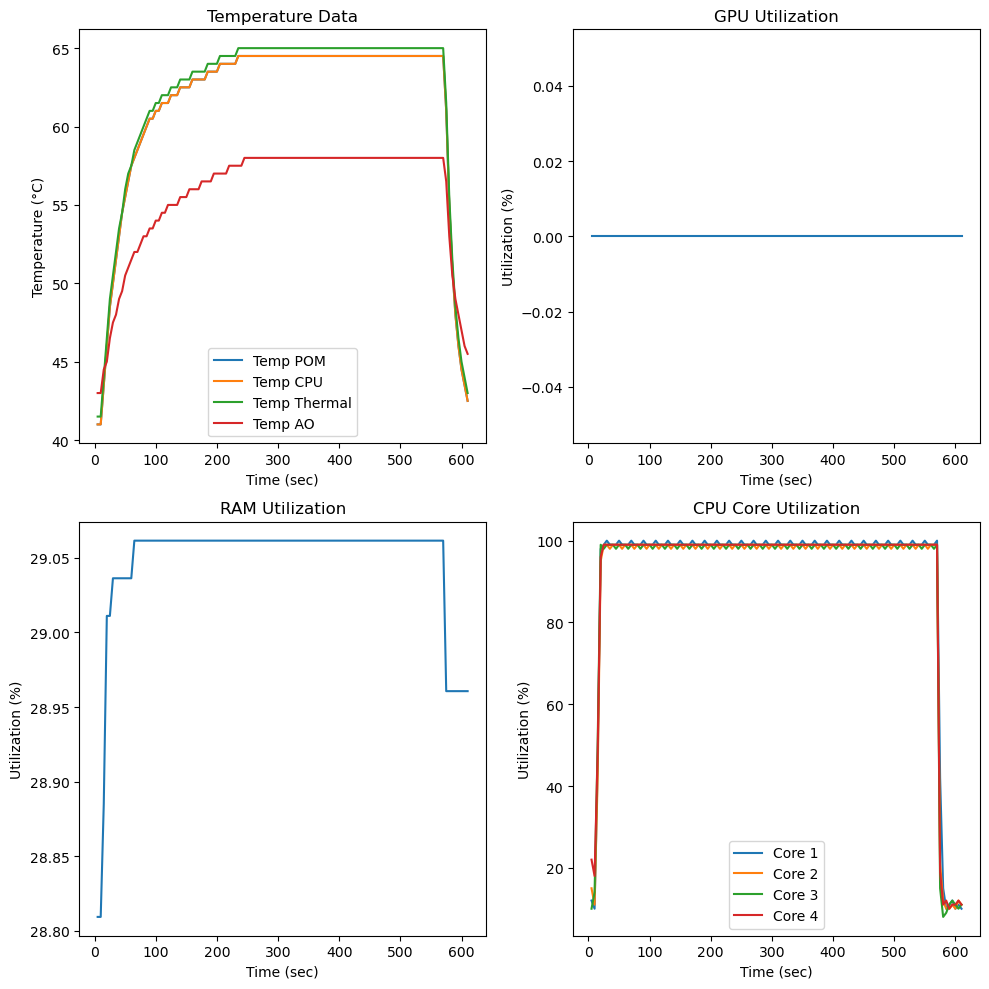

In [73]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))

axs[0,0].plot(time_s, temp_pom, label="Temp POM")
axs[0,0].plot(time_s, temp_cpu, label="Temp CPU")
axs[0,0].plot(time_s, temp_thermal, label="Temp Thermal")
axs[0,0].plot(time_s, temp_ao, label="Temp AO")
axs[0,0].set_title("Temperature Data")
axs[0,0].set_ylabel("Temperature (°C)")
axs[0,0].set_xlabel("Time (sec)")
axs[0,0].legend()

axs[0,1].plot(time_s, gpu_util)
axs[0,1].set_title("GPU Utilization")
axs[0,1].set_ylabel("Utilization (%)")
axs[0,1].set_xlabel("Time (sec)")

axs[1,0].plot(time_s, ram_util)
axs[1,0].set_title("RAM Utilization")
axs[1,0].set_ylabel("Utilization (%)")
axs[1,0].set_xlabel("Time (sec)")

for core_name in core_split.columns:
    core_data = core_split[core_name]
    axs[1,1].plot(time_s, core_data, label=core_name)

# axs[1,1].plot(time_s, ram_util)
axs[1,1].set_title("CPU Core Utilization")
axs[1,1].set_ylabel("Utilization (%)")
axs[1,1].set_xlabel("Time (sec)")
axs[1,1].legend()

plt.tight_layout()
plt.show()